<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/04wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

In [1]:
# {{<video https://youtu.be/playlist?list=PLQqh36zP38-xB7p8AzMKUrEfxL0Vte-pY&si=BwVUNxT8IIPrjIcA>}}

# 2. Imports

In [2]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. 신경망의 표현 

신경망의 표현: ${\bf X} \to \hat{\bf y}$ 로 가는 과정을 그림으로 표현

## A. 로지스틱 

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,1)}{\boldsymbol u^{(1)}} \overset{sig}{\to} \underset{(n,1)}{\boldsymbol v^{(1)}} =\underset{(n,1)}{\hat{\bf y}}$$

`-` 모든 observation과 가중치를 명시한 버전 

**(표현1)**

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-4-output-1.svg)

- 단점: 똑같은 그림의 반복이 너무 많음

`-` observation 반복을 생략한 버전들 

**(표현2)** 모든 $i$에 대하여 아래의 그림을 반복한다고 하면 (표현1)과 같다. 

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-5-output-1.svg)

**(표현3)** 그런데 (표현2)에서 아래와 같이 $x_i$, $y_i$ 대신에 간단히 $x$, $y$로 쓰는 경우도 많음

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-6-output-1.svg)

`-` 1을 생략한 버전들 

**(표현4)** bais=False 대신에 bias=True를 주면 1을 생략할 수 있음 

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-7-output-1.svg)

**(표현4의 수정)** $\hat{w}_1$대신에 $\hat{w}$를 쓰는 것이 더 자연스러움 

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-8-output-1.svg)

**(표현5)** 선형변환의 결과는 아래와 같이 $u$로 표현하기도 한다. 

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-9-output-1.svg)

> 다이어그램은 그리는 사람의 취향에 따라 그리는 방법이 조금씩 다릅니다. 즉 교재마다 달라요. 

## B. 스펙의역설 

$$\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,2)}{\boldsymbol u^{(1)}} \overset{relu}{\to} \underset{(n,2)}{\boldsymbol v^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\boldsymbol u^{(2)}} \overset{sig}{\to} \underset{(n,1)}{\boldsymbol v^{(2)}} =\underset{(n,1)}{\hat{\bf y}}$$

**참고: 코드로 표현**

```Python
torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=2),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=2,out_features=1),
    torch.nn.Sigmoid()
)
```

`-` 이해를 위해서 예젠에 다루었던 아래의 상황을 고려하자. 

![](https://guebin.github.io/DL2024/posts/03wk-2_files/figure-html/cell-11-output-1.png)

**(강의노트의 표현)**

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-10-output-1.svg)

**(좀 더 일반화된 표현)** 상황을 일반화하면 아래와 같다. 

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-11-output-1.svg)

`*` Layer의 개념: ${\bf X}$에서 $\hat{\boldsymbol y}$로 가는 과정은 "선형변환+비선형변환"이 반복되는 구조이다. "선형변환+비선형변환"을 하나의 세트로 보면 아래와 같이 표현할 수 있다. 

- $\underset{(n,1)}{\bf X}  \overset{l_1}{\to} \left( \underset{(n,2)}{\boldsymbol u^{(1)}} \overset{relu}{\to} \underset{(n,2)}{\boldsymbol v^{(1)}} \right) \overset{l_2}{\to} \left(\underset{(n,1)}{\boldsymbol u^{(2)}} \overset{sig}{\to} \underset{(n,1)}{\boldsymbol v^{(2)}}\right), \quad  \underset{(n,1)}{\boldsymbol v^{(2)}}=\underset{(n,1)}{net({\bf X})}=\underset{(n,1)}{\hat{\bf y}}$

이것을 다이어그램으로 표현한다면 아래와 같다. 

**(선형+비선형을 하나의 Layer로 묶은 표현)**

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-12-output-1.svg)

## C. 레이어를 세는방법 

`-` Layer를 세는 방법

- 제 방식: 학습가능한 파라메터가 몇층으로 있는지... <-- 이것만 기억하세여
- 일부 교재 설명: 입력층은 계산하지 않음, activation layer는 계산하지 않음. <-- 무시하세요.. 이러면 헷갈립니다.. 

`-` Hidden Layer의 수를 세는 방법

- 제 방식: `Hidden Layer의 수 = Layer의 수 -1` <-- 이걸 기억하세여..  
- 일부 교재 설명: `Layer의 수 = Hidden Layer의 수 + 출력층의 수` <-- 기억하지 마세여 

`-` 몇가지 예시들 


```Python
# 예시1 -- 2층 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
)
```

```Python
## 예시2 -- 2층 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid(),
)
```

```Python
## 예시3 -- 1층 (히든레이어는 없음!!)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
) 
```

```Python
## 예시4 -- 1층 (히든레이어는 없음!!)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
) 
```

```Python
## 예시5 -- 3층 (히든레이어는 2층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층    
) 
```

```Python
## 예시6 -- 3층 (히든레이어는 2층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU()
    torch.nn.Dropout(??)
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU()
    torch.nn.Dropout(??)
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층  
    torch.nn.Sigmoid()
) 
```

`-` 참고1: 문헌에 따라서 레이어를 세는 개념이 제가 설명한 방식과 다른경우가 있습니다. 제가 설명한 방식보다 1씩 더해서 셉니다. 즉 아래의 경우 레이어를 3개로 카운트합니다. 

```Python
## 예시1 -- 문헌에 따라 3층으로 세는 경우가 있음 (히든레이어는 1층)
torch.nn.Sequential(
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.ReLU(),
    torch.nn.Linear(??,??), ## <-- 학습해야할 가중치가 있는 층
    torch.nn.Sigmoid()
)
```

예를 들어 [여기](https://en.wikipedia.org/wiki/Multilayer_perceptron#Layers)에서는 위의 경우 레이어는 3개라고 설명하고 있습니다. 이러한 카운팅은 **"무시"하세요. 제가 설명한 방식이 맞아요.** [이 링크](https://en.wikipedia.org/wiki/Multilayer_perceptron#Layers) 잘못(?) 나와있는 이유는 아래와 같습니다. 

- 진짜 예전에 MLP를 소개할 초창기에서는 위의 경우 Layer를 3개로 셌음. [@rosenblatt1962principles]
- 그런데 시간이 지나면서 어느순간 그렇게 안세기 시작함..

참고로 히든레이어의 수는 예전방식이나 지금방식이나 동일하게 카운트하므로 히든레이어만 세면 혼돈이 없습니다. 

`-` node의 개념: $u\to v$로 가는 쌍을 간단히 노드라는 개념을 이용하여 나타낼 수 있음. 

**(노드의 개념이 포함된 그림)**

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-13-output-1.svg)

여기에서 `node의 숫자 = feature의 숫자`와 같이 이해할 수 있다. 즉 아래와 같이 이해할 수 있다. 

**("number of nodes = number of features"로 이해한 그림)**

![](https://guebin.github.io/DL2022/posts/II.%20DNN/2022-10-11-6wk-2_files/figure-html/cell-14-output-1.svg)

> 다이어그램의 표현방식은 교재마다 달라서 모든 예시를 달달 외울 필요는 없습니다. 다만 임의의 다이어그램을 보고 대응하는 네트워크를 pytorch로 구현하는 능력은 매우 중요합니다. 

# 4. 시벤코정리


`# Universal Approximation Thm` [@cybenko1989approximation]

하나의 은닉층을 가지는 아래와 같은 꼴의 네트워크 $net: {\bf X}_{n \times p} \to {\bf y}_{n\times q}$는

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(p,???),
    torch.nn.Sigmoid(),
    torch.nn.Linear(???,q)
)
```

모든 보렐 가측함수 (Borel measurable function) 

$$f: {\bf X}_{n \times p} \to {\bf y}_{n\times q}$$

를 원하는 정확도로 "근사"시킬 수 있다. 쉽게 말하면 ${\bf X} \to {\bf y}$ 인 어떠한 복잡한 규칙라도 하나의 은닉층을 가진 신경망이 원하는 정확도로 근사시킨다는 의미이다. 예를들면 아래와 같은 문제를 해결할 수 있다.

- ${\bf X}_{n\times 2}$는 토익점수, GPA 이고 ${\bf y}_{n\times 1}$는 취업여부일 경우 ${\bf X} \to {\bf y}$인 규칙을 신경망은 항상 찾을 수 있다.
- ${\bf X}_{n \times p}$는 주택이미지, 지역정보, 주택면적, 주택에 대한 설명 이고 ${\bf y}_{n\times 1}$는 주택가격일 경우 ${\bf X} \to {\bf y}$인 규칙을 신경망은 항상 찾을 수 있다.

즉 하나의 은닉층을 가진 신경망의 표현력은 거의 무한대라 볼 수 있다.

`#`



> 보렐가측함수에 대한 정의는 측도론에 대한 이해가 있어야 가능함. 측도론에 대한 내용이 궁금하다면 <https://guebin.github.io/SS2024/> 을 공부해보세요 

# 5. XOR

`-` 아래의 자료를 적합시키는 네트워크를 설계하여 보자.

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0  |

***매우 유명한 문제임***

`# 시도1` -- 어? 퀴즈11이랑 비슷하네?? 하고 적합하는경우

In [272]:
X = torch.tensor(
    [[1,0,0],[1,0,1],[1,1,0],[1,1,1]]
).float()
Y = torch.tensor([[0],[1],[1],[0]]).float()
sig = torch.nn.Sigmoid()
What = torch.randn((3,1),requires_grad=True)
loss_fn = torch.nn.BCELoss()
#---#
for epoch in range(10000):
    # step1
    Yhat = sig(X@What)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4 
    What.data = What.data - 0.1*What.grad
    What.grad = None

In [273]:
sig(X@What) # 절대 못맞춤

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)

`-` 이 규칙을 학습하기 위해서는 네트워크의 표현력이 부족함. 

$$\hat{y}_i = \text{sig}(\hat{w}_0 + \hat{w}_1 x_{i1} + \hat{w}_2 x_{i2})$$

왜? 

- 큰 $\hat{w}_0$의 값은 전체적으로 $\hat{y}_i$의 값이 1임을 의미함.. 
- 큰 $\hat{w}_1$의 값은 $x_{i1}$의 값이 커질수록 $\hat{y}_i$의 값이 커짐을 의미함
- 큰 $\hat{w}_2$의 값은 $x_{i2}$의 값이 커질수록 $\hat{y}_i$의 값이 커짐을 의미함. 

그런데 우리의 데이터는 $\hat{w}_0$의 값을 크게할지, $\hat{w}_1$을 크게할지, $\hat{w}_2$의 값을 크게할지 모두 애매하다.. 

`-` 우리는 매우 불리한 상황임. 데이터가 아래와 같이 생겼다면 맞췄을 것임 

(예시1)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1  |

(예시2)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0  |

하다 못해 아래와 같은 상황이라도 맞췃을 것임 

(예시3)

| ${\bf x}_1$ | ${\bf x}_2$ | ${\bf y}$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 0 | 1 |
| 0 | 1 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |
| 1 | 1 | 1 |

`# 시도2`

`-` X1을 학점, X2를 토익점수, Y를 취업여부라고 상상한다면?? 

- 데이터가 말하는건 X1과 X2가 모두 큰데 오히려 취업이 안되는 상황 
- 시도1이 실패한건 표현력이 부족했기 때문임

In [274]:
X = torch.tensor(
    [[0,0],[0,1],[1,0],[1,1]]
).float()
Y = torch.tensor([[0],[1],[1],[0]]).float()
net = torch.nn.Sequential(
    torch.nn.Linear(2,2),
    torch.nn.ReLU(),
    torch.nn.Linear(2,1),
    torch.nn.Sigmoid()

)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#

In [275]:
for epoch in range(1000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4 
    optimizer.step()
    optimizer.zero_grad()

In [276]:
net(X).data,Y

(tensor([[0.5066],
         [0.4974],
         [0.5037],
         [0.4945]]),
 tensor([[0.],
         [1.],
         [1.],
         [0.]]))

`# 시도3` -- 좀더 화끈하게 (시벤코정리 고마웡)

In [278]:
X = torch.tensor(
    [[0,0],[0,1],[1,0],[1,1]]
).float()
Y = torch.tensor([[0],[1],[1],[0]]).float()
net = torch.nn.Sequential(
    torch.nn.Linear(2,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,1),
    torch.nn.Sigmoid()

)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(1000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4 
    optimizer.step()
    optimizer.zero_grad()

In [279]:
net(X).data,Y

(tensor([[0.0076],
         [0.9931],
         [0.9932],
         [0.0067]]),
 tensor([[0.],
         [1.],
         [1.],
         [0.]]))

# 5. 전통적 모델링 vs 딥러닝식 모델링

## A. 자유낙하 

`-` 박혜원씨는 물체가 떨어진 높이와 물체가 지면에 떨어지는 시간이 어떠한 관계가 있다는 것을 알았다. 구체적으로 

> 높은곳에서 떨어진 물체일수록 더 오랜시간 낙하함. 

와 같은 관계가 있다는 사실을 알았다. 

In [17]:
height = [ 
    0.1867,  0.2848,  2.1355,  2.2167,  4.1491,  8.1850,  8.7433,  9.3315,
    14.5883, 14.9888, 16.5491, 17.7069, 18.8424, 21.8355, 21.8808, 22.0881,
    22.3026, 22.5745, 23.1269, 23.9332, 24.6669, 27.2351, 27.4392, 27.6720,
    28.1114, 29.1729, 29.2594, 30.6107, 30.7007, 31.9626, 32.4375, 33.5212,
    33.8969, 35.3980, 35.4875, 36.0210, 36.7319, 37.2270, 37.7999, 37.9642,
    38.5938, 39.0878, 39.3041, 39.5966, 41.6302, 43.3391, 43.4646, 43.4779,
    44.2029, 44.5496, 45.1828, 47.0924, 47.5687, 48.3803, 49.7113, 49.9602,
    50.4318, 50.5070, 50.5837, 51.3863, 51.3869, 52.9359, 53.6882, 54.3114,
    56.0177, 60.8485, 62.5412, 64.0429, 64.4687, 65.6608, 65.7108, 67.0237,
    67.1796, 68.4925, 69.4765, 70.7629, 71.0061, 71.1954, 71.3918, 74.0178,
    77.3426, 77.5536, 78.2571, 79.4971, 79.6985, 80.0267, 80.4075, 83.2470,
    84.7562, 85.1897, 85.7150, 87.1619, 90.8313, 91.7407, 92.3853, 93.5739,
    96.1382, 96.9394, 99.0074, 99.6843
]

In [18]:
fall_time = [
    0.0612, 0.1882, 0.7556, 0.6769, 0.9018, 1.3658, 1.4047, 1.2397, 1.8347,
    1.7617, 1.8318, 1.7867, 1.9896, 2.0901, 2.0347, 2.0704, 2.1524, 2.1035,
    2.1703, 1.9836, 2.3152, 2.3836, 2.4949, 2.3455, 2.5333, 2.2178, 2.4416,
    2.5534, 2.6200, 2.6332, 2.5955, 2.5901, 2.5771, 2.8369, 2.7254, 2.7138,
    2.7489, 2.7782, 2.7200, 2.7547, 2.6128, 2.8415, 2.7808, 2.6488, 3.1167,
    3.0383, 2.9401, 3.0126, 2.9233, 3.1341, 3.0755, 2.9978, 3.1484, 3.1864,
    3.3868, 3.2313, 3.1209, 3.1922, 3.2119, 3.1101, 3.3041, 3.3947, 3.1918,
    3.4043, 3.3920, 3.4561, 3.7133, 3.5496, 3.6964, 3.7211, 3.5275, 3.7168,
    3.6911, 3.6120, 3.8650, 3.9209, 3.7195, 3.9642, 3.8094, 3.9951, 4.2356,
    3.9031, 3.8805, 3.8605, 4.1031, 3.9385, 4.0645, 4.2283, 4.1582, 4.1910,
    4.0181, 4.2427, 4.4362, 4.4256, 4.4554, 4.4870, 4.4486, 4.4710, 4.4710,
    4.4741
]

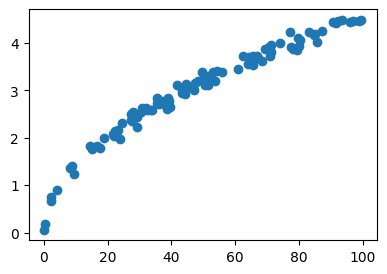

In [20]:
plt.plot(height,fall_time,'o')

**만약에 높이 49m에서 떨어뜨리면, 몇초만에 떨어질까?**

## B. 전통적 모델링 

`-` 그래프를 보면 높이가 높을 수록 낙하시간도 길어지는 경향이 보임. 

- 다만 동일한 높이라 하더라도 낙하시간이 조금씩 차이날 수 있어보임
- 이는 사람이 시간측정을 수동으로 하며 발생하는 실험오차 때문인것 같음


`-` 아무튼 오차에도 불구하고 `height`와 `fall_time`은 일정한 규칙(=오차랑 관련없는 underlying structure)이 존재하는 듯 하다. 


`-` **자문요청**: 물리학과 교수님께 자문을 요청한 결과 

$$\text{자유낙하시간} \propto \sqrt{\text{높이}}$$

임을 알 수 있었다.


`-` 이를 근거로 아래와 같은 모형을 설계하였다. 

$$t_i = \beta_1 \sqrt{h}_i + \epsilon_i, \quad \epsilon_i \sim N(0,??)$$

`-` 적합: $y_i = t_i$로, $x_i=\sqrt{h}_i$로 해석하자. 

In [32]:
X = torch.sqrt(torch.tensor(height)).reshape(-1,1)
Y = torch.tensor(fall_time).reshape(-1,1)

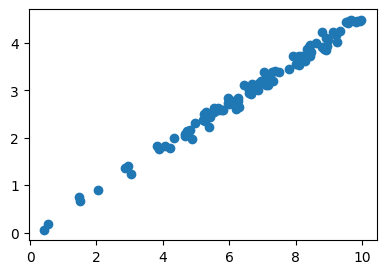

In [139]:
plt.plot(X,Y,'o') # 적당한 변환을 샥샥 해주니까... 회귀네?

In [57]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(1,1,bias=False)
)
# 이건 사실 net = torch.nn.Linear(1,1,bais=False) 와 같은 효과임
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(100):
    ## step1
    Yhat = net(X)
    ## step2
    loss = loss_fn(Yhat,Y)
    ## step3
    loss.backward()
    ## step4
    optimizer.step()
    optimizer.zero_grad()

In [124]:
for epoch in range(100):
    ## step1
    Yhat = net(X)
    ## step2
    loss = loss_fn(Yhat,Y)
    ## step3
    loss.backward()
    ## step4
    optimizer.step()
    optimizer.zero_grad()

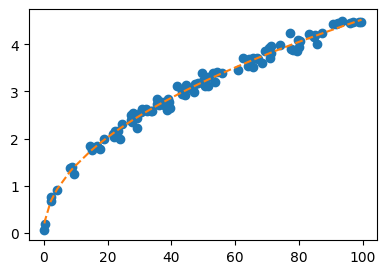

In [125]:
#plt.plot(height,fall_time,'o')
plt.plot(X**2,Y,'o')
plt.plot(X**2,net(X).data,'--')

`-` 예측: 만약 높이 50m에서 떨어뜨리면 몇초만에 떨어질까? 

In [130]:
list(net.parameters())

[Parameter containing:
 tensor([[0.4530]], requires_grad=True)]

In [138]:
Xnew = torch.sqrt(torch.tensor([[50]]))
net(Xnew).data

tensor([[3.2034]])

## C. 딥러닝식 모델링 

`-` 참모델? 관심없음 

`-` 그냥 딥러닝식 무지성적합 (underlying structure가 뭔지 알게 뭐야)

In [167]:
X = torch.tensor(height).reshape(-1,1)
Y = torch.tensor(fall_time).reshape(-1,1)
# 천하무적 네트워크
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())

In [174]:
for epoch in range(100):
    # step1
    Yhat = net(X)
    # step2 
    loss = loss_fn(Yhat,Y)
    # step3 
    loss.backward()
    # step4 
    optimizer.step()
    optimizer.zero_grad()

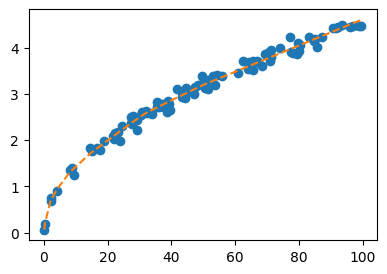

In [175]:
plt.plot(X,Y,'o')
plt.plot(X,net(X).data,'--')

In [176]:
Xnew = torch.tensor([[50.00]])
net(Xnew).data

tensor([[3.1976]])

- 쓸만한데? 

`-` true가 아닐지라도 쓸만함. 

> "All models are wrong (but some are useful)", George Box

ref: <https://en.wikipedia.org/wiki/All_models_are_wrong> 

`-` 너무나 유명한 그림 (ref: <https://www.ncbi.nlm.nih.gov/books/NBK543533/>)

![](https://www.ncbi.nlm.nih.gov/books/NBK543533/bin/463627_1_En_BookFrontmatter_Fig1_HTML.jpg)

# 6. MNIST

## A. 예비학습 -- `plt.imshow()`

`-` `plt.imshow(..., cmap="gray")` 에서 `...`이 shape이 (??,??)이면 흑백이미지를 출력

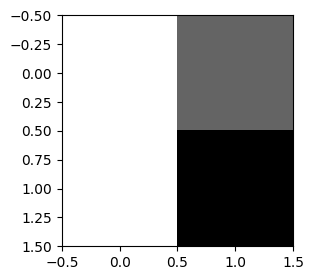

In [ ]:
img = torch.tensor([[255,100],
                    [255,0]])
plt.imshow(img,cmap="gray")

`-` `plt.imshow(...)` 에서 `...`의 shape이 (??,??,3)이면 칼라이미지를 출력

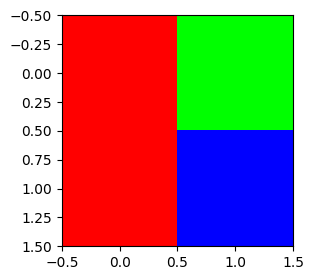

In [ ]:
r = torch.tensor([[255,0],
                  [255,0]])
g = torch.tensor([[0,255],
                  [0,0]])
b = torch.tensor([[0,0],
                  [0,255]])
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

`-` `plt.imshow(...)` 에서 `...`의 자료형이 int인지 float인지에 따라서 인식이 다름

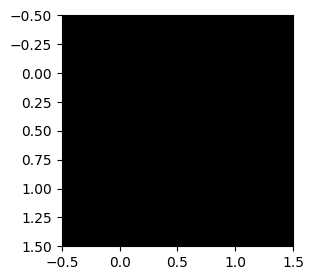

In [ ]:
r = torch.tensor([[1,0],
                  [1,0]])
g = torch.tensor([[0,1],
                  [0,0]])
b = torch.tensor([[0,0],
                  [0,1]])
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

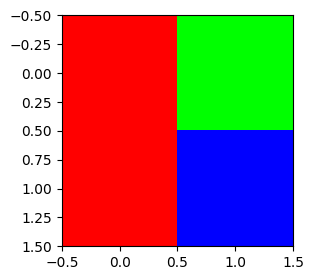

In [ ]:
r = torch.tensor([[255,0],
                  [255,0]])/255
g = torch.tensor([[0,255],
                  [0,0]])/255
b = torch.tensor([[0,0],
                  [0,255]])/255
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

## B. 데이터

`-` 데이터 정리코드

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3])
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7])
X = torch.concat([X3,X7],axis=0)
y = torch.tensor([0.0]*len(X3) + [1.0]*len(X7))

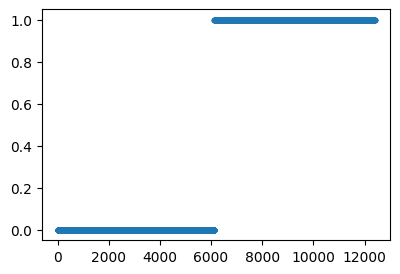

In [ ]:
plt.plot(y,'.')

`-` 우리는 ${\bf X}: (n,1,28,28)$ 에서 ${\bf y}: (n,1)$으로 가는 맵핑을 배우고 싶음. $\to$ 이런건 배운적이 없는데?.. $\to$ 그렇다면 ${\bf X}:(n,784) \to {\bf y}:(n,1)$ 으로 가는 맵핑을 학습하자.

In [ ]:
X = torch.stack([img.reshape(-1) for img in X])
y = y.reshape(-1,1)

In [ ]:
X.shape,y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

## C. 학습

In [ ]:
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
for epoc in range(200):
    ## 1 
    yhat = net(X) 
    ## 2 
    loss = loss_fn(yhat,y)
    ## 3
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad()

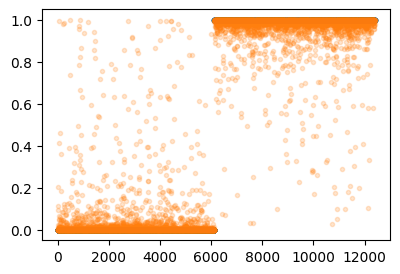

In [ ]:
plt.plot(y,'.')
plt.plot(net(X).data,'.',alpha=0.2)

In [ ]:
((y == (net(X).data > 0.5))*1.0).mean()

tensor(0.9901)

:::{.callout-note}

**이미지자료의 차원**

- 칼라이미지데이터 ${\bf X}$는 (n,3,h,w) 의 차원을 가지거나 (n,h,w,3)의 차원을 가진다. 
- 흑백이미지데이터 ${\bf X}$는 (n,h,w) 의 차원을 가지거나 (n,1,h,w)의 차원을 가지거나 (n,h,w,1)의 차원을 가진다. 

:::